#  Experiment 11: Advanced Features

## Temporal Modeling + Duration Encoding + IBM Quantum

This notebook demonstrates three advanced improvements:

1. **Temporal Modeling** - Markov transitions for sequence structure
2. **Duration Encoding** - 6-qubit model (pitch + duration)
3. **IBM Quantum** - Run on real quantum hardware

---

In [1]:
# Setup
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from src.models.qcbm import QCBM, create_entangled_qcbm
from src.models.temporal import MarkovQCBM, SecondOrderMarkovQCBM
from src.data.encoder import PitchEncoder
from src.data.duration_encoder import DurationEncoder, PitchDurationEncoder
from src.data.midi_parser import MidiParser, export_to_midi, Note
from src.training.trainer import train_qcbm
from src.utils.visualization import set_style
from src.utils.figure_saver import save_figure
from config import FIGURES_DIR, RANDOM_SEED

set_style()
np.random.seed(RANDOM_SEED)
print(" Setup complete!")

 Setup complete!


---
# Part 1: Temporal Modeling with Markov QCBM

Standard QCBM samples notes independently (i.i.d.). This creates random sequences without musical structure.

**Markov QCBM** adds temporal dependencies:
$$P(x_t | x_{t-1}) \propto P_{\text{QCBM}}(x_t) \cdot T(x_t | x_{t-1})$$

where $T$ is a learned transition matrix from training data.

In [2]:
# Load champion configuration from experiments
import json

with open(FIGURES_DIR / 'exp07_optimizer_results.json') as f:
    exp07 = json.load(f)
    CHAMPION_OPTIMIZER = exp07['winner']

with open(FIGURES_DIR / 'exp06_topology_results.json') as f:
    exp06 = json.load(f)
    CHAMPION_TOPOLOGY = exp06['winner']

print(f" Champion Configuration:")
print(f"   Topology: {CHAMPION_TOPOLOGY}")
print(f"   Optimizer: {CHAMPION_OPTIMIZER}")
print(f"   Loss: MMD (from exp08)")

 Champion Configuration:
   Topology: linear
   Optimizer: SLSQP
   Loss: MMD (from exp08)


In [3]:
# Load and parse Mario MIDI
parser = MidiParser('../mario.mid')
parser.parse()
notes = parser.notes

print(f" Loaded {len(notes)} notes from Mario")

# Create encoder
N_QUBITS = 4
encoder = PitchEncoder(n_qubits=N_QUBITS)
pitches = [n.pitch for n in notes]
encoder.fit(pitches)

print(f"   Pitch range: {min(pitches)} - {max(pitches)}")
print(f"   Bins: {encoder.n_bins}")

 Loaded 5435 notes from Mario
   Pitch range: 26 - 95
   Bins: 16


In [4]:
# Create and train base QCBM
qcbm = create_entangled_qcbm(n_qubits=N_QUBITS, n_layers=3)
target_dist = encoder.get_distribution(np.array(pitches))

print(" Training base QCBM...")
result = train_qcbm(
    qcbm=qcbm,
    target_distribution=target_dist,
    n_iterations=200,
    loss_function='mmd',  # Champion from exp08
    optimizer=CHAMPION_OPTIMIZER,  # Champion from exp07
    verbose=True,
    seed=RANDOM_SEED
)
trained_params = result.final_params
print(f"\n Training complete! Fidelity: {result.final_fidelity:.4f}")

 Training base QCBM...


Training QCBM:   0%|          | 0/200 [00:00<?, ?it/s]/home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../src/training/trainer.py:206: OptimizeWarning: Unknown solver options: maxfev
  result = minimize(
Training QCBM:   1%|          | 2/200 [00:00<00:02, 92.60it/s, loss=0.1690, fidelity=0.7919]/home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../src/training/trainer.py:206: OptimizeWarning: Unknown solver options: maxfev
  result = minimize(
Training QCBM: 750it [00:05, 139.49it/s, loss=0.0001, fidelity=0.9516]                         


 Training complete! Fidelity: 0.9516


In [5]:
# Create Markov QCBM
markov_qcbm = MarkovQCBM(qcbm, transition_strength=0.5)

# Fit transitions from Mario data
markov_qcbm.fit_from_notes(notes, encoder)

print(" Learned Transition Matrix:")
print(f"   Shape: {markov_qcbm.transition_matrix.shape}")
print(f"   Non-uniform rows: {np.sum(np.std(markov_qcbm.transition_matrix, axis=1) > 0.1)}")

 Learned Transition Matrix:
   Shape: (16, 16)
   Non-uniform rows: 4


 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp11_markov_transition_matrix.png


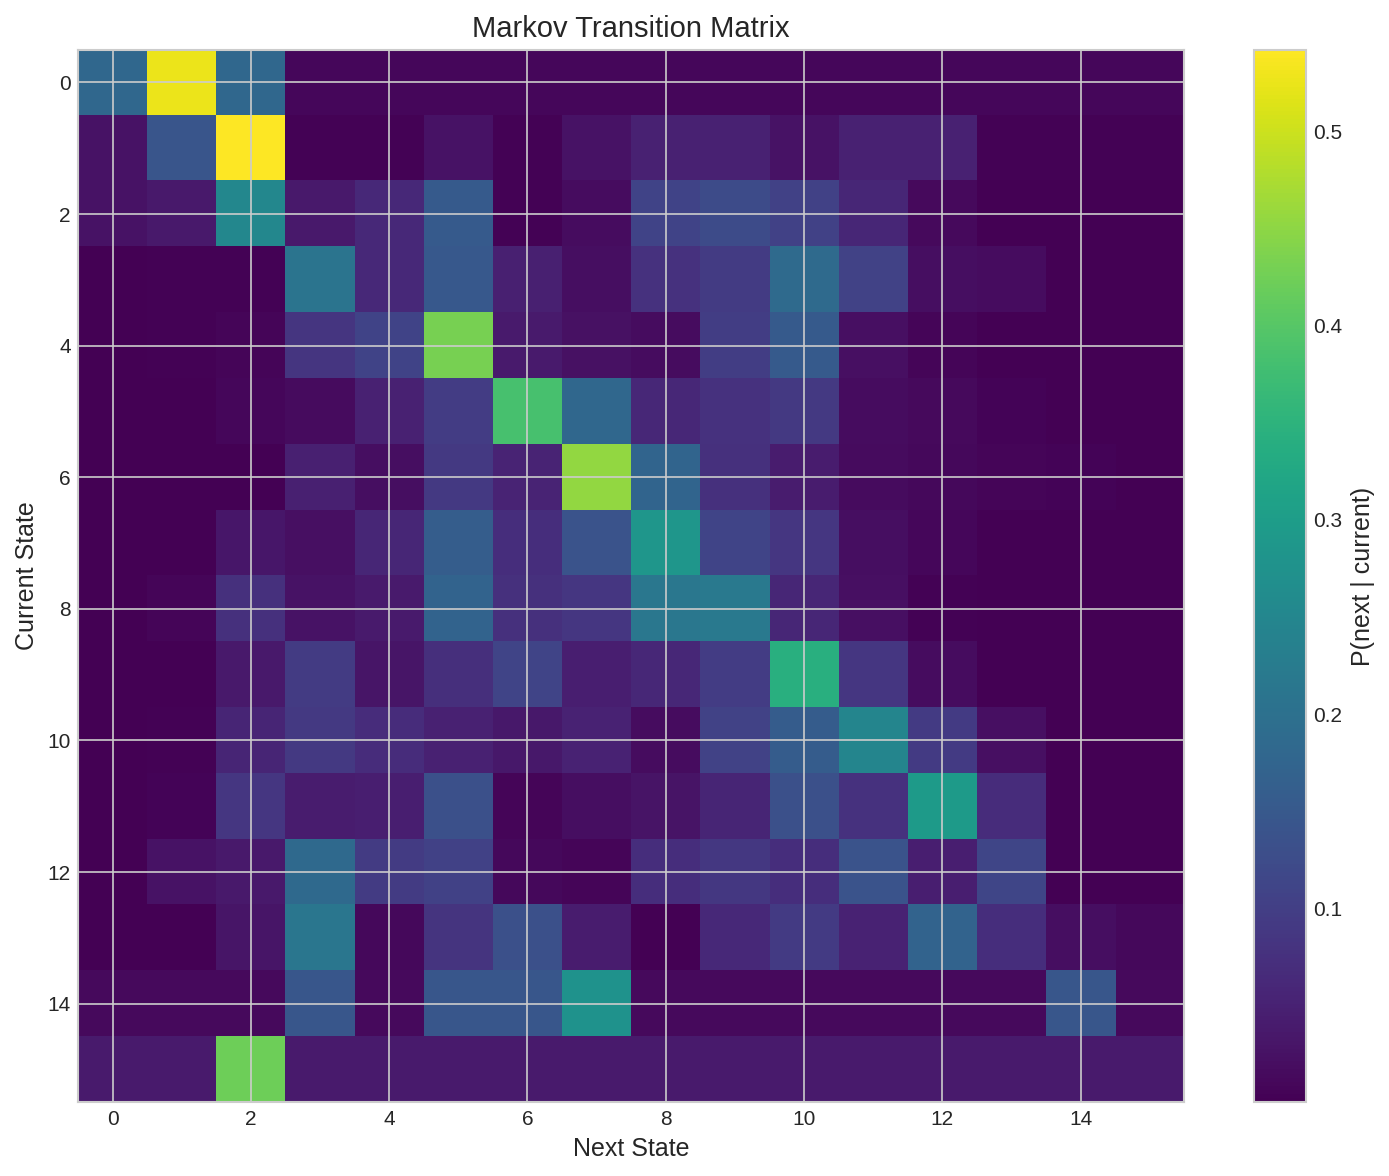

In [6]:
# Visualize transition matrix
fig, ax = plt.subplots(figsize=(10, 8))
markov_qcbm.visualize_transitions(ax)
plt.tight_layout()
save_figure(fig, 'markov_transition_matrix', experiment='exp11')
plt.show()

In [7]:
# Compare: Standard QCBM vs Markov QCBM sampling
N_SAMPLES = 50

# Standard i.i.d. sampling
standard_samples = qcbm.sample(trained_params, n_samples=N_SAMPLES)
standard_pitches = [encoder.decode(s) for s in standard_samples]

# Markov-guided sampling
markov_samples = markov_qcbm.generate_sequence(
    trained_params, 
    length=N_SAMPLES,
    temperature=1.0
)
markov_pitches = [encoder.decode(s) for s in markov_samples]

print(f" Sample Statistics:")
print(f"\n   Standard QCBM (i.i.d.):")
print(f"   - Unique pitches: {len(set(standard_pitches))}")
print(f"   - Mean interval: {np.mean(np.abs(np.diff(standard_pitches))):.2f} semitones")

print(f"\n   Markov QCBM:")
print(f"   - Unique pitches: {len(set(markov_pitches))}")
print(f"   - Mean interval: {np.mean(np.abs(np.diff(markov_pitches))):.2f} semitones")

 Sample Statistics:

   Standard QCBM (i.i.d.):
   - Unique pitches: 13
   - Mean interval: 17.86 semitones

   Markov QCBM:
   - Unique pitches: 9
   - Mean interval: 10.62 semitones


 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp11_standard_vs_markov_sampling.png


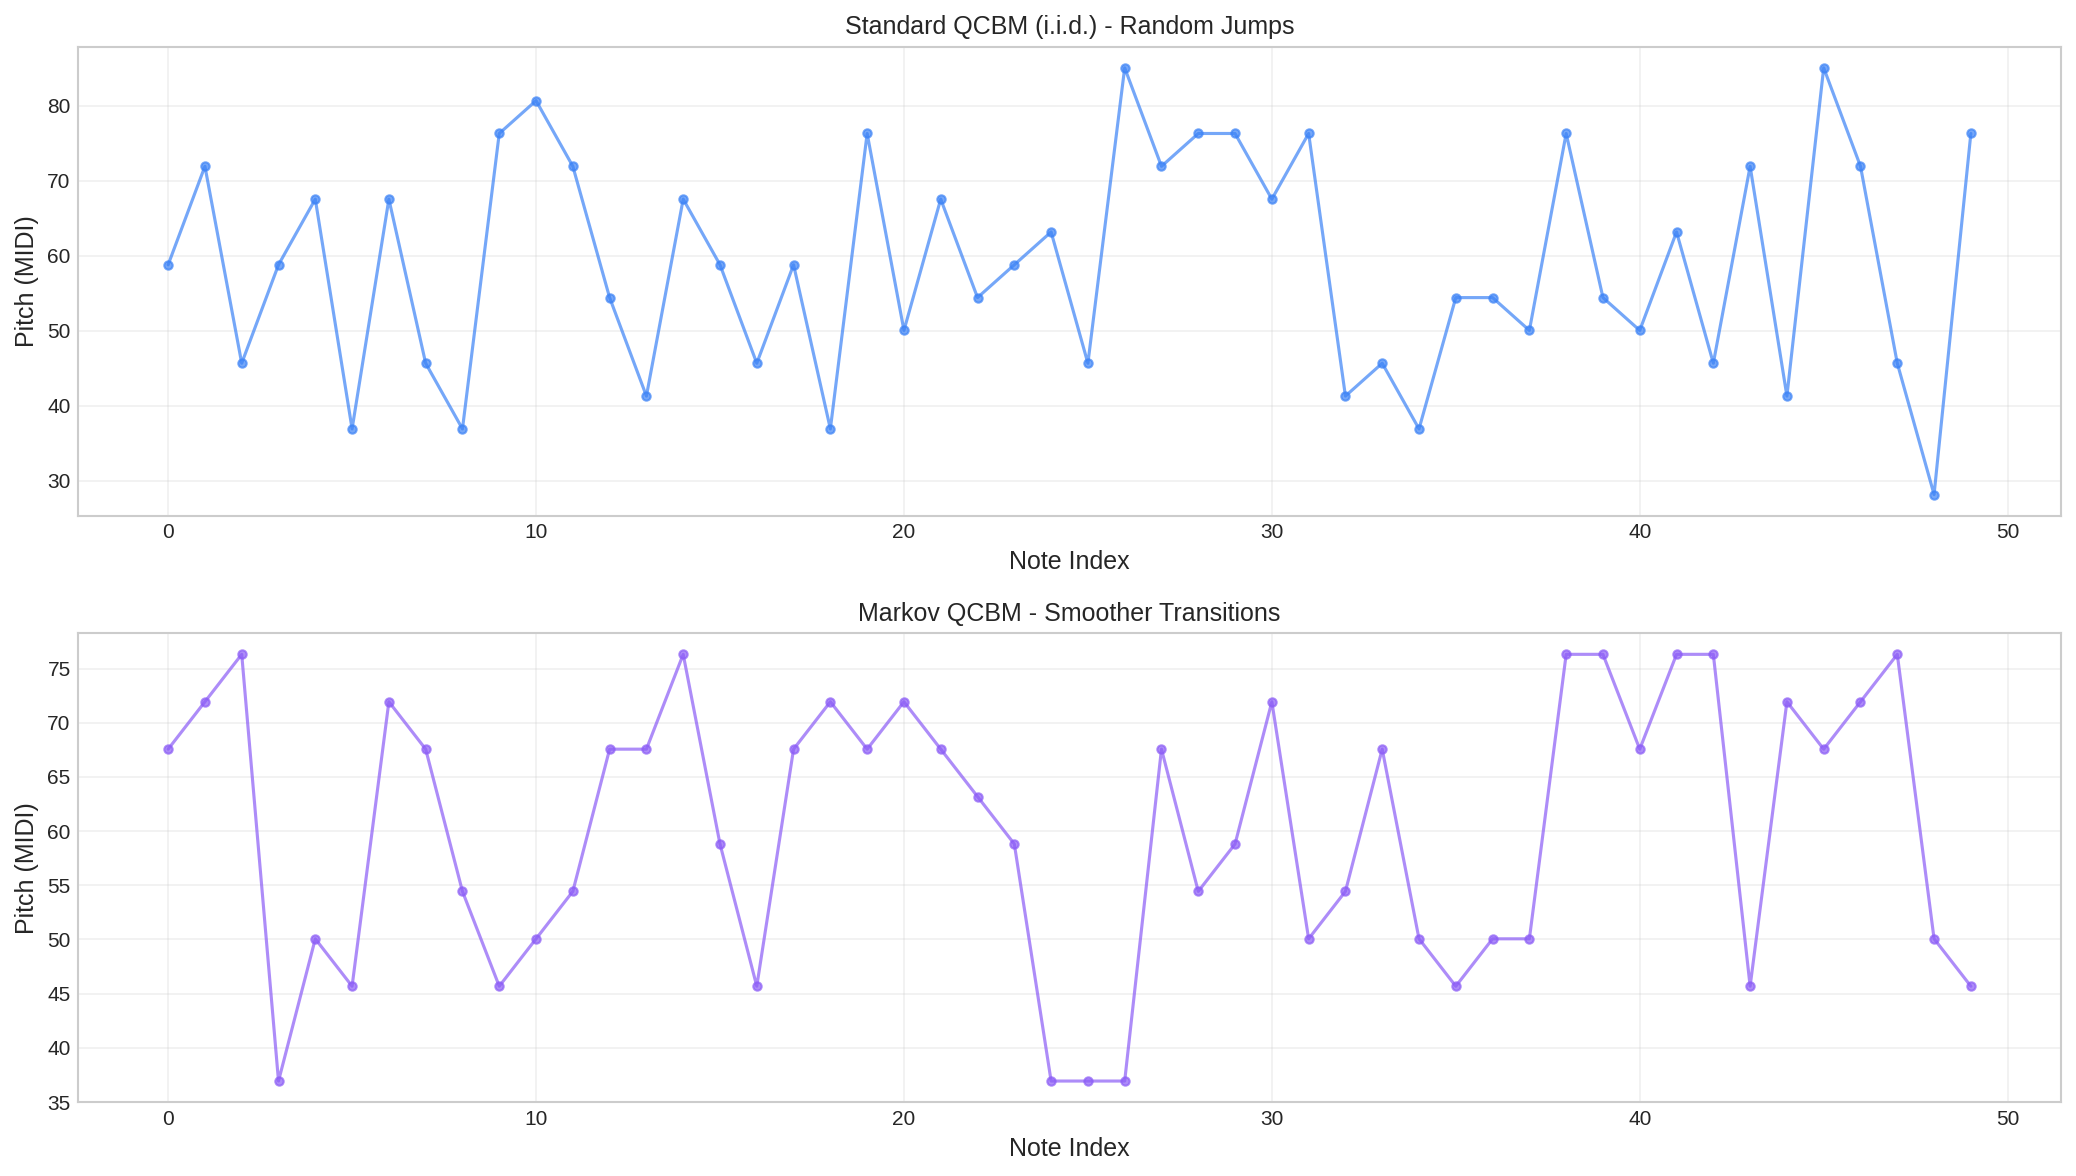

In [8]:
# Visualize the difference
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Standard QCBM - jumpy
axes[0].plot(standard_pitches, 'o-', color='#3B82F6', alpha=0.7, markersize=4)
axes[0].set_title('Standard QCBM (i.i.d.) - Random Jumps', fontsize=12)
axes[0].set_xlabel('Note Index')
axes[0].set_ylabel('Pitch (MIDI)')
axes[0].grid(True, alpha=0.3)

# Markov QCBM - smoother
axes[1].plot(markov_pitches, 'o-', color='#8B5CF6', alpha=0.7, markersize=4)
axes[1].set_title('Markov QCBM - Smoother Transitions', fontsize=12)
axes[1].set_xlabel('Note Index')
axes[1].set_ylabel('Pitch (MIDI)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_figure(fig, 'standard_vs_markov_sampling', experiment='exp11')
plt.show()

In [9]:
# Export Markov-generated melody
def create_melody(pitches, tempo=120, note_duration=0.25):
    seconds_per_beat = 60.0 / tempo
    notes = []
    for i, pitch in enumerate(pitches):
        note = Note(
            pitch=pitch,
            velocity=80,
            start_time=i * note_duration * seconds_per_beat,
            duration=note_duration * seconds_per_beat * 0.9
        )
        notes.append(note)
    return notes

markov_notes = create_melody(markov_pitches)
export_to_midi(markov_notes, str(FIGURES_DIR / '03_markov_qcbm_temporal_coherence.mid'), tempo=120)
print(f" Markov melody saved to {FIGURES_DIR / '03_markov_qcbm_temporal_coherence.mid'}")

 Markov melody saved to /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/03_markov_qcbm_temporal_coherence.mid


---
# Part 2: Duration Encoding (6-Qubit Model)

Extend from pitch-only (4 qubits) to pitch + duration (6 qubits):
- **4 qubits**: 16 pitch bins
- **2 qubits**: 4 duration bins (sixteenth, eighth, quarter, half+)
- **Total**: 64 joint states

This captures the correlation: *"fast passages use short notes, slow melodies use long notes"*

In [10]:
# Create duration encoder
duration_encoder = DurationEncoder(n_qubits=2, tempo=120)

# Analyze Mario's duration distribution
durations = [n.duration for n in notes]
duration_dist = duration_encoder.get_distribution(np.array(durations))

print(" Duration Analysis:")
print(f"   Duration range: {min(durations):.3f} - {max(durations):.3f} seconds")
print(f"   Duration bins: {duration_encoder.n_bins}")
print(f"\n   Distribution:")
labels = ['16th', '8th', '4th', 'half+']
for i, (label, prob) in enumerate(zip(labels, duration_dist)):
    print(f"   - {label}: {prob:.2%}")

 Duration Analysis:
   Duration range: 117.000 - 17237.000 seconds
   Duration bins: 4

   Distribution:
   - 16th: 0.00%
   - 8th: 0.00%
   - 4th: 0.00%
   - half+: 100.00%


In [11]:
# Create joint pitch-duration encoder
joint_encoder = PitchDurationEncoder(
    n_qubits_pitch=4,
    n_qubits_duration=2,
    tempo=120
)

# Fit to Mario data
joint_encoder.fit(pitches, durations)

print(f" Joint Encoder Configuration:")
print(f"   Total qubits: {joint_encoder.n_qubits_total}")
print(f"   Pitch qubits: {joint_encoder.n_qubits_pitch} ({joint_encoder.n_pitch_bins} bins)")
print(f"   Duration qubits: {joint_encoder.n_qubits_duration} ({joint_encoder.n_duration_bins} bins)")
print(f"   Total states: {joint_encoder.n_states}")

 Joint Encoder Configuration:
   Total qubits: 6
   Pitch qubits: 4 (16 bins)
   Duration qubits: 2 (4 bins)
   Total states: 64


In [12]:
# Compute joint distribution
joint_dist = joint_encoder.get_joint_distribution(
    np.array(pitches), 
    np.array(durations)
)

print(f" Joint Distribution:")
print(f"   Non-zero states: {np.sum(joint_dist > 0.001)}")
print(f"   Max probability: {np.max(joint_dist):.4f}")
print(f"   Entropy: {-np.sum(joint_dist * np.log2(joint_dist + 1e-10)):.2f} bits")

 Joint Distribution:
   Non-zero states: 15
   Max probability: 0.1295
   Entropy: 3.51 bits


 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp11_joint_pitch_duration_distribution.png


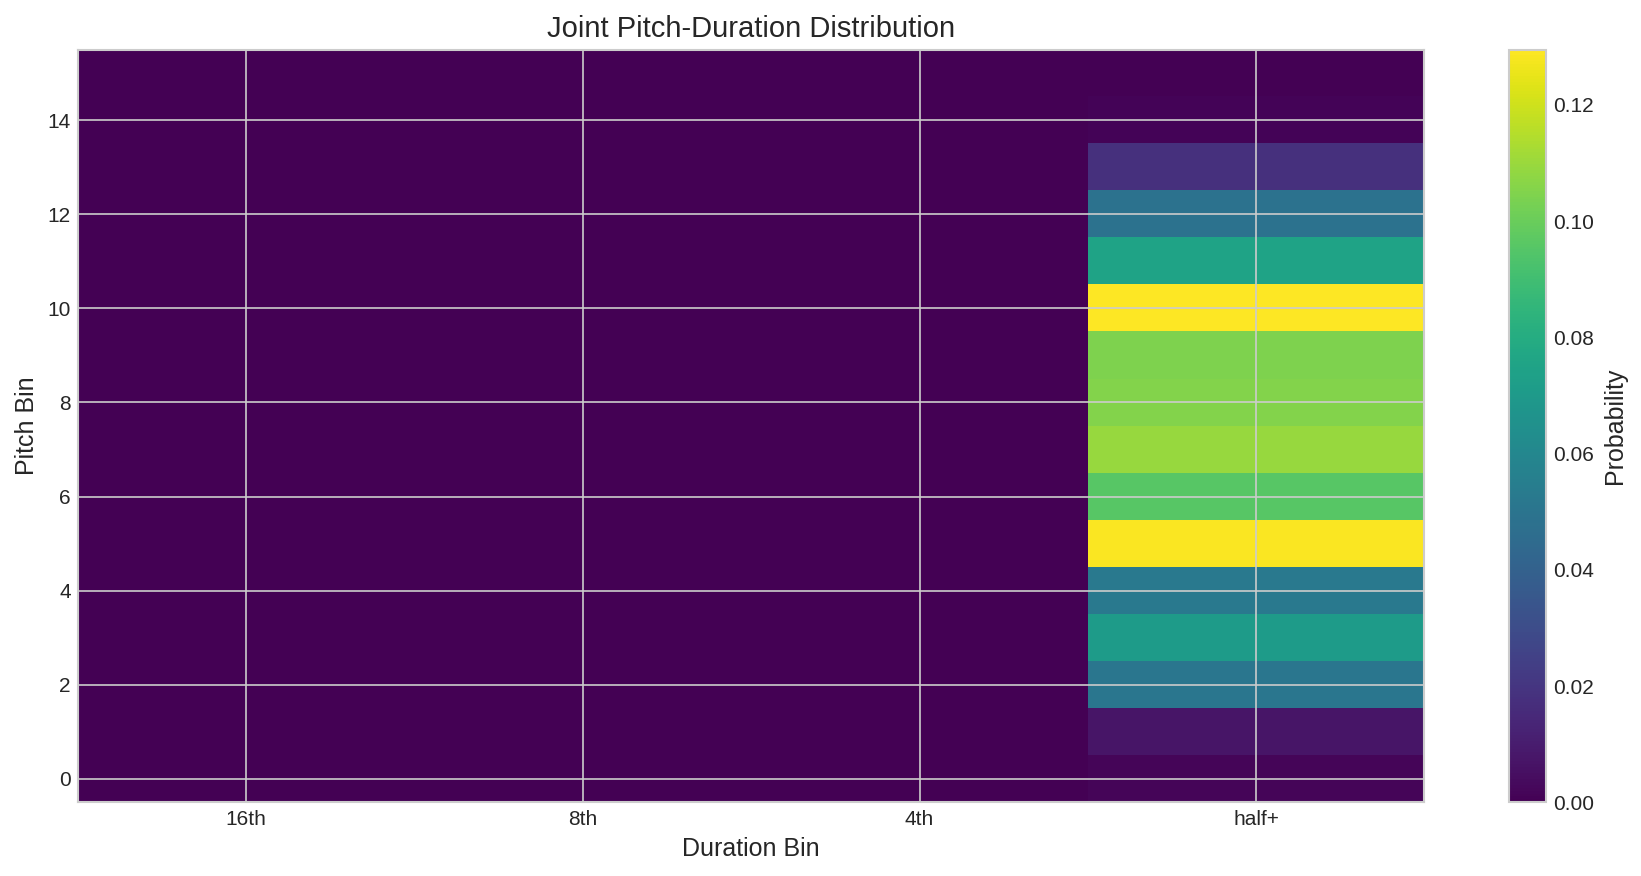

In [13]:
# Visualize joint distribution
fig, ax = plt.subplots(figsize=(12, 6))
joint_encoder.visualize_joint_distribution(joint_dist, ax)
plt.tight_layout()
save_figure(fig, 'joint_pitch_duration_distribution', experiment='exp11')
plt.show()

In [14]:
# Train 6-qubit QCBM on joint distribution
print(" Training 6-qubit QCBM on joint pitch-duration distribution...")

qcbm_6q = create_entangled_qcbm(n_qubits=6, n_layers=3)

result_6q = train_qcbm(
    qcbm=qcbm_6q,
    target_distribution=joint_dist,
    n_iterations=300,
    loss_function='mmd',  # Champion from exp08
    optimizer=CHAMPION_OPTIMIZER,  # Champion from exp07
    verbose=True,
    seed=RANDOM_SEED
)

print(f"\n Training complete!")
print(f"   Final fidelity: {result_6q.final_fidelity:.4f}")
print(f"   Parameters: {qcbm_6q.n_params}")

 Training 6-qubit QCBM on joint pitch-duration distribution...


Training QCBM:   0%|          | 0/300 [00:00<?, ?it/s]/home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../src/training/trainer.py:206: OptimizeWarning: Unknown solver options: maxfev
  result = minimize(
Training QCBM:   0%|          | 1/300 [00:00<00:05, 50.50it/s, loss=0.1223, fidelity=0.4072]/home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../src/training/trainer.py:206: OptimizeWarning: Unknown solver options: maxfev
  result = minimize(
Training QCBM: 1851it [00:22, 81.56it/s, loss=0.0001, fidelity=0.5069]                        


 Training complete!
   Final fidelity: 0.5069
   Parameters: 36


In [15]:
# Generate samples with duration
N_SAMPLES = 50
joint_samples = qcbm_6q.sample(result_6q.final_params, n_samples=N_SAMPLES)

# Decode to pitches and durations
gen_pitches, gen_durations = joint_encoder.decode(joint_samples)

print(f" Generated {N_SAMPLES} notes with pitch and duration:")
print(f"\n   First 10 notes:")
for i in range(10):
    print(f"   - Pitch: {gen_pitches[i]:.0f}, Duration: {gen_durations[i]:.3f}s")

 Generated 50 notes with pitch and duration:

   First 10 notes:
   - Pitch: 54, Duration: 0.188s
   - Pitch: 46, Duration: 0.188s
   - Pitch: 68, Duration: 1.000s
   - Pitch: 59, Duration: 0.375s
   - Pitch: 46, Duration: 0.188s
   - Pitch: 63, Duration: 0.062s
   - Pitch: 37, Duration: 0.188s
   - Pitch: 76, Duration: 1.000s
   - Pitch: 50, Duration: 1.000s
   - Pitch: 68, Duration: 1.000s


In [16]:
# Create melody with variable durations
def create_melody_with_durations(pitches, durations, tempo=120):
    notes = []
    current_time = 0.0
    
    for pitch, duration in zip(pitches, durations):
        note = Note(
            pitch=pitch,
            velocity=80,
            start_time=current_time,
            duration=duration * 0.9  # Slight gap
        )
        notes.append(note)
        current_time += duration
    
    return notes

# Export melody with variable durations
duration_notes = create_melody_with_durations(gen_pitches, gen_durations)
export_to_midi(
    duration_notes, 
    str(FIGURES_DIR / '04_joint_pitch_rhythm_qcbm.mid'), 
    tempo=120
)

print(f" Melody with durations saved!")
print(f"   Total duration: {sum(gen_durations):.2f} seconds")

 Melody with durations saved!
   Total duration: 23.75 seconds


---
# Part 3: IBM Quantum Hardware

Run the QCBM on real quantum hardware using IBM Quantum.

**Requirements:**
1. Install Qiskit: `pip install qiskit qiskit-ibm-runtime qiskit-aer`
2. Create IBM Quantum account: https://quantum.ibm.com/
3. Get API token from your IBM Quantum dashboard

**Note:** Hardware jobs may take minutes to hours depending on queue.

In [17]:
# Check if Qiskit is available
try:
    from src.models.ibm_backend import QiskitQCBM, HardwareConfig, save_ibm_credentials
    QISKIT_AVAILABLE = True
    print(" Qiskit is available!")
except ImportError as e:
    QISKIT_AVAILABLE = False
    print(f" Qiskit not available: {e}")
    print("   Install with: pip install qiskit qiskit-ibm-runtime qiskit-aer")

 Qiskit is available!


In [18]:
if QISKIT_AVAILABLE:
    # Create Qiskit-based QCBM
    qiskit_qcbm = QiskitQCBM(
        n_qubits=4,
        n_layers=3,
        topology='full'
    )
    
    print(f" Qiskit QCBM Configuration:")
    print(f"   Qubits: {qiskit_qcbm.n_qubits}")
    print(f"   Layers: {qiskit_qcbm.n_layers}")
    print(f"   Parameters: {qiskit_qcbm.n_params}")
    print(f"   States: {qiskit_qcbm.n_states}")

 Qiskit QCBM Configuration:
   Qubits: 4
   Layers: 3
   Parameters: 24
   States: 16


In [19]:
if QISKIT_AVAILABLE:
    # Draw the circuit
    print(" Circuit Diagram:")
    print(qiskit_qcbm.draw_circuit())

 Circuit Diagram:
        ┌─────────┐┌─────────┐               ┌─────────┐┌─────────┐            »
   q_0: ┤ Ry(θ_0) ├┤ Rz(θ_1) ├──■────■────■──┤ Ry(θ_8) ├┤ Rz(θ_9) ├────────────»
        ├─────────┤├─────────┤┌─┴─┐  │    │  └─────────┘└─────────┘┌──────────┐»
   q_1: ┤ Ry(θ_2) ├┤ Rz(θ_3) ├┤ X ├──┼────┼───────■──────────■─────┤ Ry(θ_10) ├»
        ├─────────┤├─────────┤└───┘┌─┴─┐  │     ┌─┴─┐        │     └──────────┘»
   q_2: ┤ Ry(θ_4) ├┤ Rz(θ_5) ├─────┤ X ├──┼─────┤ X ├────────┼──────────■──────»
        ├─────────┤├─────────┤     └───┘┌─┴─┐   └───┘      ┌─┴─┐      ┌─┴─┐    »
   q_3: ┤ Ry(θ_6) ├┤ Rz(θ_7) ├──────────┤ X ├──────────────┤ X ├──────┤ X ├────»
        └─────────┘└─────────┘          └───┘              └───┘      └───┘    »
meas: 4/═══════════════════════════════════════════════════════════════════════»
                                                                               »
«                                          ┌──────────┐┌──────────┐            »
«   q_0: ─

In [20]:
if QISKIT_AVAILABLE:
    # Run on LOCAL SIMULATOR (no IBM account needed)
    print(" Running on local Qiskit Aer simulator...")
    
    # Use the trained PennyLane parameters
    # (or generate new random ones)
    test_params = qiskit_qcbm.get_initial_params(seed=RANDOM_SEED)
    
    # Get probabilities from simulator
    sim_probs = qiskit_qcbm.get_probabilities_simulator(test_params)
    
    print(f"\n Simulator Results:")
    print(f"   Top 5 states:")
    top_indices = np.argsort(sim_probs)[-5:][::-1]
    for idx in top_indices:
        print(f"   - State {idx} ({qiskit_qcbm.circuit.num_qubits}b): {sim_probs[idx]:.4f}")

 Running on local Qiskit Aer simulator...

 Simulator Results:
   Top 5 states:
   - State 13 (4b): 0.1917
   - State 11 (4b): 0.1199
   - State 14 (4b): 0.1125
   - State 7 (4b): 0.0913
   - State 9 (4b): 0.0801

 Simulator Results:
   Top 5 states:
   - State 13 (4b): 0.1917
   - State 11 (4b): 0.1199
   - State 14 (4b): 0.1125
   - State 7 (4b): 0.0913
   - State 9 (4b): 0.0801


In [23]:
if QISKIT_AVAILABLE:
    # Compare Qiskit simulator with target distribution
    from src.training.loss_functions import mmd_loss, fidelity
    
    # Train Qiskit QCBM on simulator (simplified training)
    from scipy.optimize import minimize
    
    def loss_fn(params):
        probs = qiskit_qcbm.get_probabilities_simulator(params)
        return mmd_loss(probs, target_dist)
    
    print(" Training Qiskit QCBM on simulator...")
    init_params = qiskit_qcbm.get_initial_params(seed=RANDOM_SEED)
    
    result_qiskit = minimize(
        loss_fn,
        init_params,
        method=CHAMPION_OPTIMIZER,  # Use champion optimizer instead of hardcoded 'Powell'
        options={'maxiter': 100}
    )
    
    final_probs = qiskit_qcbm.get_probabilities_simulator(result_qiskit.x)
    final_fidelity = fidelity(final_probs, target_dist)
    
    print(f"\n Training complete with {CHAMPION_OPTIMIZER}!")
    print(f"   Final fidelity: {final_fidelity:.4f}")
    print(f"   Final loss: {result_qiskit.fun:.6f}")

 Training Qiskit QCBM on simulator...

 Training complete with SLSQP!
   Final fidelity: 0.8053
   Final loss: 0.087255

 Training complete with SLSQP!
   Final fidelity: 0.8053
   Final loss: 0.087255


 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp11_qiskit_simulator_results.png


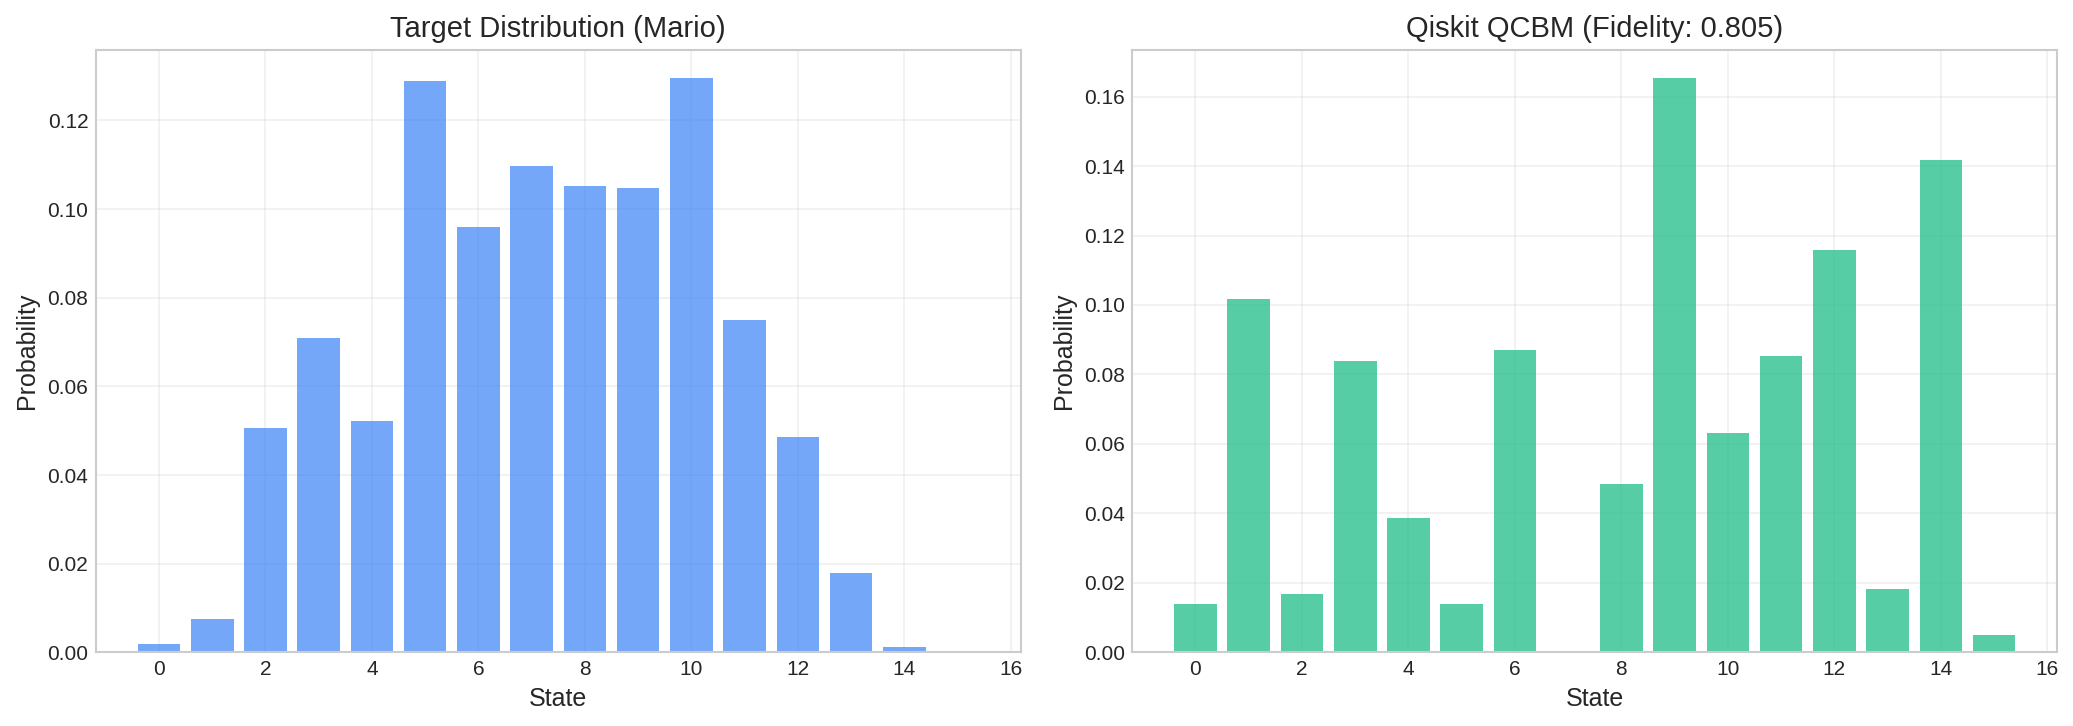

In [24]:
if QISKIT_AVAILABLE:
    # Visualize Qiskit results
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Target
    axes[0].bar(range(len(target_dist)), target_dist, color='#3B82F6', alpha=0.7)
    axes[0].set_title('Target Distribution (Mario)')
    axes[0].set_xlabel('State')
    axes[0].set_ylabel('Probability')
    axes[0].grid(True, alpha=0.3)
    
    # Qiskit
    axes[1].bar(range(len(final_probs)), final_probs, color='#10B981', alpha=0.7)
    axes[1].set_title(f'Qiskit QCBM (Fidelity: {final_fidelity:.3f})')
    axes[1].set_xlabel('State')
    axes[1].set_ylabel('Probability')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    save_figure(fig, 'qiskit_simulator_results', experiment='exp11')
    plt.show()

###  Connect to Real IBM Quantum Hardware

**To run on real hardware:**

1. Get your API token from https://quantum.ibm.com/
2. Uncomment and run the cells below
3. Jobs may queue for several minutes

In [25]:
#  STEP 1: Save your IBM Quantum API token (ONLY RUN ONCE!)
#  CREDENTIALS ALREADY SAVED - No need to run again!

if QISKIT_AVAILABLE:
    # Reload the module to get the fixed version
    import importlib
    import src.models.ibm_backend as ibm_backend
    importlib.reload(ibm_backend)
    from src.models.ibm_backend import save_ibm_credentials
    
    # Uncomment and add your token if you need to re-save
    # save_ibm_credentials("YOUR_TOKEN_HERE", overwrite=True)
    print(" Using previously saved credentials")

 Using previously saved credentials


In [26]:
#  STEP 2: List available backends first
if QISKIT_AVAILABLE:
    from qiskit_ibm_runtime import QiskitRuntimeService
    
    # Connect to service
    service = QiskitRuntimeService()
    
    # List available backends
    print(" Available IBM Quantum backends:")
    backends = service.backends()
    for backend in backends:
        print(f"   - {backend.name}: {backend.num_qubits} qubits")

qiskit_runtime_service.__init__:WARNING:2026-02-06 13:12:48,778: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-02-06 13:12:48,779: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-02-06 13:12:48,779: Loading instance: open-instance, plan: open


 Available IBM Quantum backends:
   - ibm_fez: 156 qubits
   - ibm_fez: 156 qubits
   - ibm_torino: 133 qubits
   - ibm_torino: 133 qubits
   - ibm_marrakesh: 156 qubits
   - ibm_marrakesh: 156 qubits


In [28]:
#  STEP 3: Connect to IBM Quantum with champion topology
if QISKIT_AVAILABLE:
    # Create Qiskit-based QCBM with champion topology
    qiskit_qcbm = QiskitQCBM(
        n_qubits=4,
        n_layers=3,
        topology=CHAMPION_TOPOLOGY  # Use champion topology instead of hardcoded 'full'
    )
    
    print(f" Qiskit QCBM Configuration:")
    print(f"   Qubits: {qiskit_qcbm.n_qubits}")
    print(f"   Layers: {qiskit_qcbm.n_layers}")
    print(f"   Topology: {CHAMPION_TOPOLOGY}")
    print(f"   Parameters: {qiskit_qcbm.n_params}")
    print(f"   States: {qiskit_qcbm.n_states}")
    
    # Connect to IBM Quantum
    qiskit_qcbm.connect_to_ibm()
    
    # Display hardware info
    hw_info = qiskit_qcbm.get_hardware_info()
    print("\n Hardware Info:")
    print(f"   Topology: {CHAMPION_TOPOLOGY}")
    for key, value in hw_info.items():
        print(f"   {key}: {value}")

 Qiskit QCBM Configuration:
   Qubits: 4
   Layers: 3
   Topology: linear
   Parameters: 24
   States: 16


qiskit_runtime_service.__init__:WARNING:2026-02-06 13:15:28,010: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-02-06 13:15:28,011: Using instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-02-06 13:15:28,011: Using instance: open-instance, plan: open


 Connected to IBM Quantum
   Backend: ibm_torino
   Qubits: 133
   Qubits: 133
   Status: active
   Status: active

 Hardware Info:
   Topology: linear
   name: ibm_torino
   num_qubits: 133
   basis_gates: ['x', 'rz', 'cz', 'delay', 'id', 'reset', 'measure', 'sx', 'if_else']
   status: active
   pending_jobs: 0

 Hardware Info:
   Topology: linear
   name: ibm_torino
   num_qubits: 133
   basis_gates: ['x', 'rz', 'cz', 'delay', 'id', 'reset', 'measure', 'sx', 'if_else']
   status: active
   pending_jobs: 0


---
##  Hardware Validation Experiment

### What We Are Doing

We validate our QCBM by running the **same trained circuit** on:
1. **Qiskit Aer Simulator** - Perfect, noise-free quantum simulation
2. **IBM Quantum Hardware** (`ibm_torino`) - Real 133-qubit quantum computer

### Why This Matters

Real quantum computers suffer from:
- **Gate errors** (~0.1-1% per gate)
- **Decoherence** (qubits lose information over time)
- **Readout errors** (~1-5% measurement errors)

By comparing simulator vs. hardware, we quantify **how much noise affects our QCBM**.

### Metrics We Measure

| Metric | Formula | Meaning |
|--------|---------|---------|
| **Simulator Fidelity** | $F(P_{sim}, P_{target})$ | How well simulator learned the target |
| **Hardware Fidelity** | $F(P_{hw}, P_{target})$ | How well hardware reproduces target |
| **Noise Degradation** | $F_{sim} - F_{hw}$ | Performance loss due to noise |
| **Sim-HW Agreement** | $F(P_{sim}, P_{hw})$ | How close hardware is to simulator |

In [29]:
#  Step 1: Prepare the experiment
# We use the parameters trained on the Qiskit simulator (result_qiskit.x)

print("="*70)
print(" HARDWARE VALIDATION EXPERIMENT")
print("="*70)

print("\n Experiment Configuration:")
print(f"   Circuit: {qiskit_qcbm.n_qubits} qubits, {qiskit_qcbm.n_layers} layers")
print(f"   Parameters: {qiskit_qcbm.n_params}")
print(f"   Backend: {qiskit_qcbm.hardware_config.backend_name}")
print(f"   Shots: {qiskit_qcbm.hardware_config.shots}")

print("\n Baseline (Simulator Results):")
print(f"   Simulator Fidelity with Target: {final_fidelity:.4f}")

# Store for comparison
experiment_results = {
    'n_qubits': qiskit_qcbm.n_qubits,
    'n_layers': qiskit_qcbm.n_layers,
    'n_params': qiskit_qcbm.n_params,
    'backend': qiskit_qcbm.hardware_config.backend_name,
    'shots': qiskit_qcbm.hardware_config.shots,
    'simulator_fidelity': float(final_fidelity),
    'trained_params': result_qiskit.x.tolist()
}

 HARDWARE VALIDATION EXPERIMENT

 Experiment Configuration:
   Circuit: 4 qubits, 3 layers
   Parameters: 24
   Backend: ibm_torino
   Shots: 4096

 Baseline (Simulator Results):
   Simulator Fidelity with Target: 0.8053


In [32]:
#  Step 2: Run on REAL IBM Quantum Hardware
# This submits a job to ibm_torino and waits for results

from src.training.loss_functions import fidelity
import time

# Reload the module to get the fixed API
importlib.reload(ibm_backend)

# Recreate and reconnect with champion topology
qiskit_qcbm = ibm_backend.QiskitQCBM(
    n_qubits=4, 
    n_layers=3, 
    topology=CHAMPION_TOPOLOGY  # Use variable, not string literal
)
qiskit_qcbm.connect_to_ibm()

print("\n Submitting job to IBM Quantum hardware...")
print(f"   Backend: {qiskit_qcbm.hardware_config.backend_name}")
print(f"   Topology: {CHAMPION_TOPOLOGY}")  # Show which topology is being used
print("    This may take several minutes depending on queue...")
print()

start_time = time.time()

# Run on real hardware with error mitigation
hardware_probs = qiskit_qcbm.run_on_hardware(
    result_qiskit.x,
    error_mitigation=True
)

elapsed_time = time.time() - start_time

print(f"\n Job completed in {elapsed_time:.1f} seconds!")
print(f"   Received {len(hardware_probs)} probability values")

qiskit_runtime_service.__init__:WARNING:2026-02-06 13:16:37,232: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-02-06 13:16:37,233: Using instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-02-06 13:16:37,233: Using instance: open-instance, plan: open


 Connected to IBM Quantum
   Backend: ibm_torino
   Qubits: 133
   Qubits: 133
   Status: active

 Submitting job to IBM Quantum hardware...
   Backend: ibm_torino
   Topology: linear
    This may take several minutes depending on queue...

 Submitting job to ibm_torino...
   Circuit depth: 31
   Gate count: OrderedDict({'rz': 34, 'sx': 31, 'cz': 9, 'measure': 4, 'barrier': 1})
   Status: active

 Submitting job to IBM Quantum hardware...
   Backend: ibm_torino
   Topology: linear
    This may take several minutes depending on queue...

 Submitting job to ibm_torino...
   Circuit depth: 31
   Gate count: OrderedDict({'rz': 34, 'sx': 31, 'cz': 9, 'measure': 4, 'barrier': 1})
   Job ID: d62tna2o8gvs73f2lmc0
   Waiting for results...
   Job ID: d62tna2o8gvs73f2lmc0
   Waiting for results...
 Hardware execution complete!

 Job completed in 8.0 seconds!
   Received 16 probability values
 Hardware execution complete!

 Job completed in 8.0 seconds!
   Received 16 probability values


In [33]:
#  Step 3: Compute Comparison Metrics

# Calculate all fidelity metrics
hw_fidelity = fidelity(hardware_probs, target_dist)
sim_hw_fidelity = fidelity(final_probs, hardware_probs)
noise_degradation = final_fidelity - hw_fidelity

print("="*70)
print(" HARDWARE VALIDATION RESULTS")
print("="*70)

print("\n Fidelity Metrics:")
print(f"   Simulator → Target:    {final_fidelity:.4f}")
print(f"   Hardware  → Target:    {hw_fidelity:.4f}")
print(f"   Simulator → Hardware:  {sim_hw_fidelity:.4f}")

print(f"\n Noise Impact:")
print(f"   Fidelity degradation:  {noise_degradation:.4f} ({noise_degradation/final_fidelity*100:.1f}% loss)")

print(f"\n Distribution Statistics:")
print(f"   Hardware max prob:     {np.max(hardware_probs):.4f}")
print(f"   Hardware entropy:      {-np.sum(hardware_probs * np.log2(hardware_probs + 1e-10)):.2f} bits")

# Update experiment results
experiment_results['hardware_fidelity'] = float(hw_fidelity)
experiment_results['sim_hw_fidelity'] = float(sim_hw_fidelity)
experiment_results['noise_degradation'] = float(noise_degradation)
experiment_results['noise_degradation_percent'] = float(noise_degradation/final_fidelity*100)
experiment_results['hardware_probs'] = hardware_probs.tolist()
experiment_results['simulator_probs'] = final_probs.tolist()
experiment_results['target_probs'] = target_dist.tolist()

 HARDWARE VALIDATION RESULTS

 Fidelity Metrics:
   Simulator → Target:    0.8053
   Hardware  → Target:    0.7495
   Simulator → Hardware:  0.9333

 Noise Impact:
   Fidelity degradation:  0.0558 (6.9% loss)

 Distribution Statistics:
   Hardware max prob:     0.1548
   Hardware entropy:      3.61 bits


 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp11_hardware_validation_comparison.png


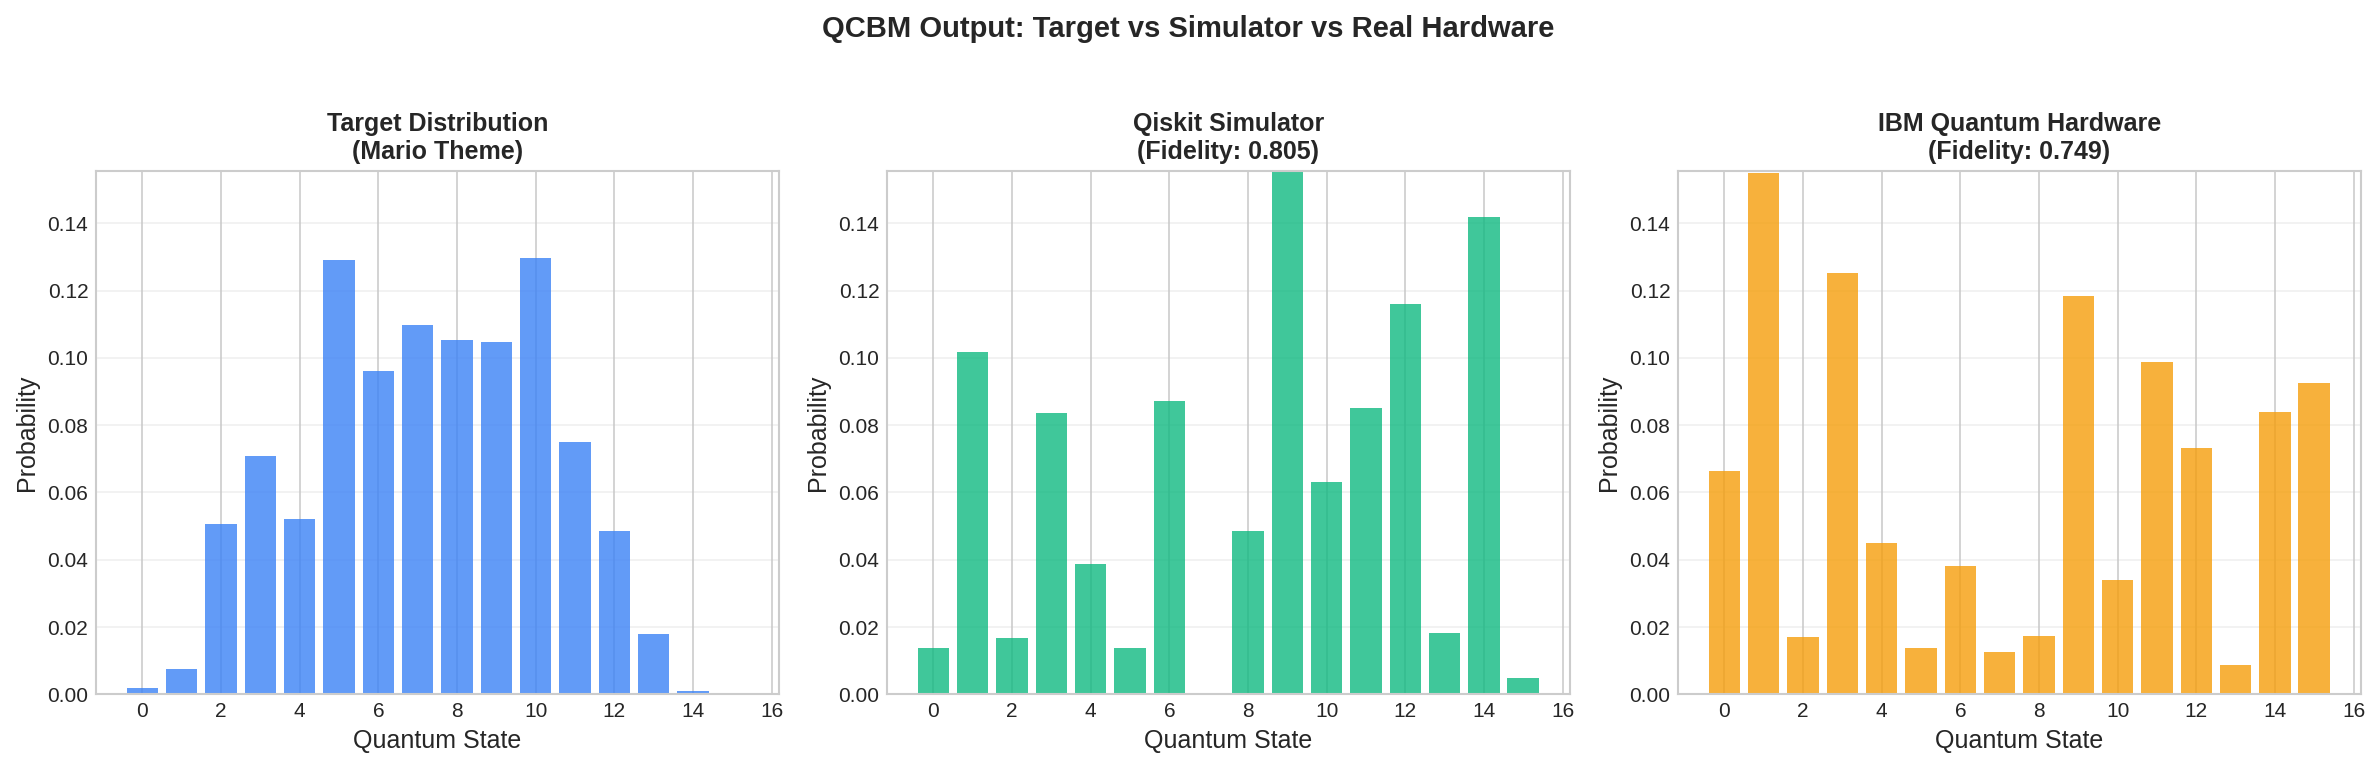


 Figure saved to /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp11_hardware_validation_comparison.png


In [34]:
#  Step 4: Visualize Comparison (Main Figure for Report)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

states = range(len(target_dist))
bar_width = 0.8

# Plot 1: Target Distribution
axes[0].bar(states, target_dist, color='#3B82F6', alpha=0.8, width=bar_width)
axes[0].set_title('Target Distribution\n(Mario Theme)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Quantum State')
axes[0].set_ylabel('Probability')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(0, max(target_dist) * 1.2)

# Plot 2: Simulator Distribution  
axes[1].bar(states, final_probs, color='#10B981', alpha=0.8, width=bar_width)
axes[1].set_title(f'Qiskit Simulator\n(Fidelity: {final_fidelity:.3f})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Quantum State')
axes[1].set_ylabel('Probability')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(0, max(target_dist) * 1.2)

# Plot 3: Hardware Distribution
axes[2].bar(states, hardware_probs, color='#F59E0B', alpha=0.8, width=bar_width)
axes[2].set_title(f'IBM Quantum Hardware\n(Fidelity: {hw_fidelity:.3f})', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Quantum State')
axes[2].set_ylabel('Probability')
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].set_ylim(0, max(target_dist) * 1.2)

plt.suptitle('QCBM Output: Target vs Simulator vs Real Hardware', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_figure(fig, 'hardware_validation_comparison', experiment='exp11')
plt.show()

print(f"\n Figure saved to {FIGURES_DIR}/exp11_hardware_validation_comparison.png")

 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp11_hardware_vs_simulator_overlay.png


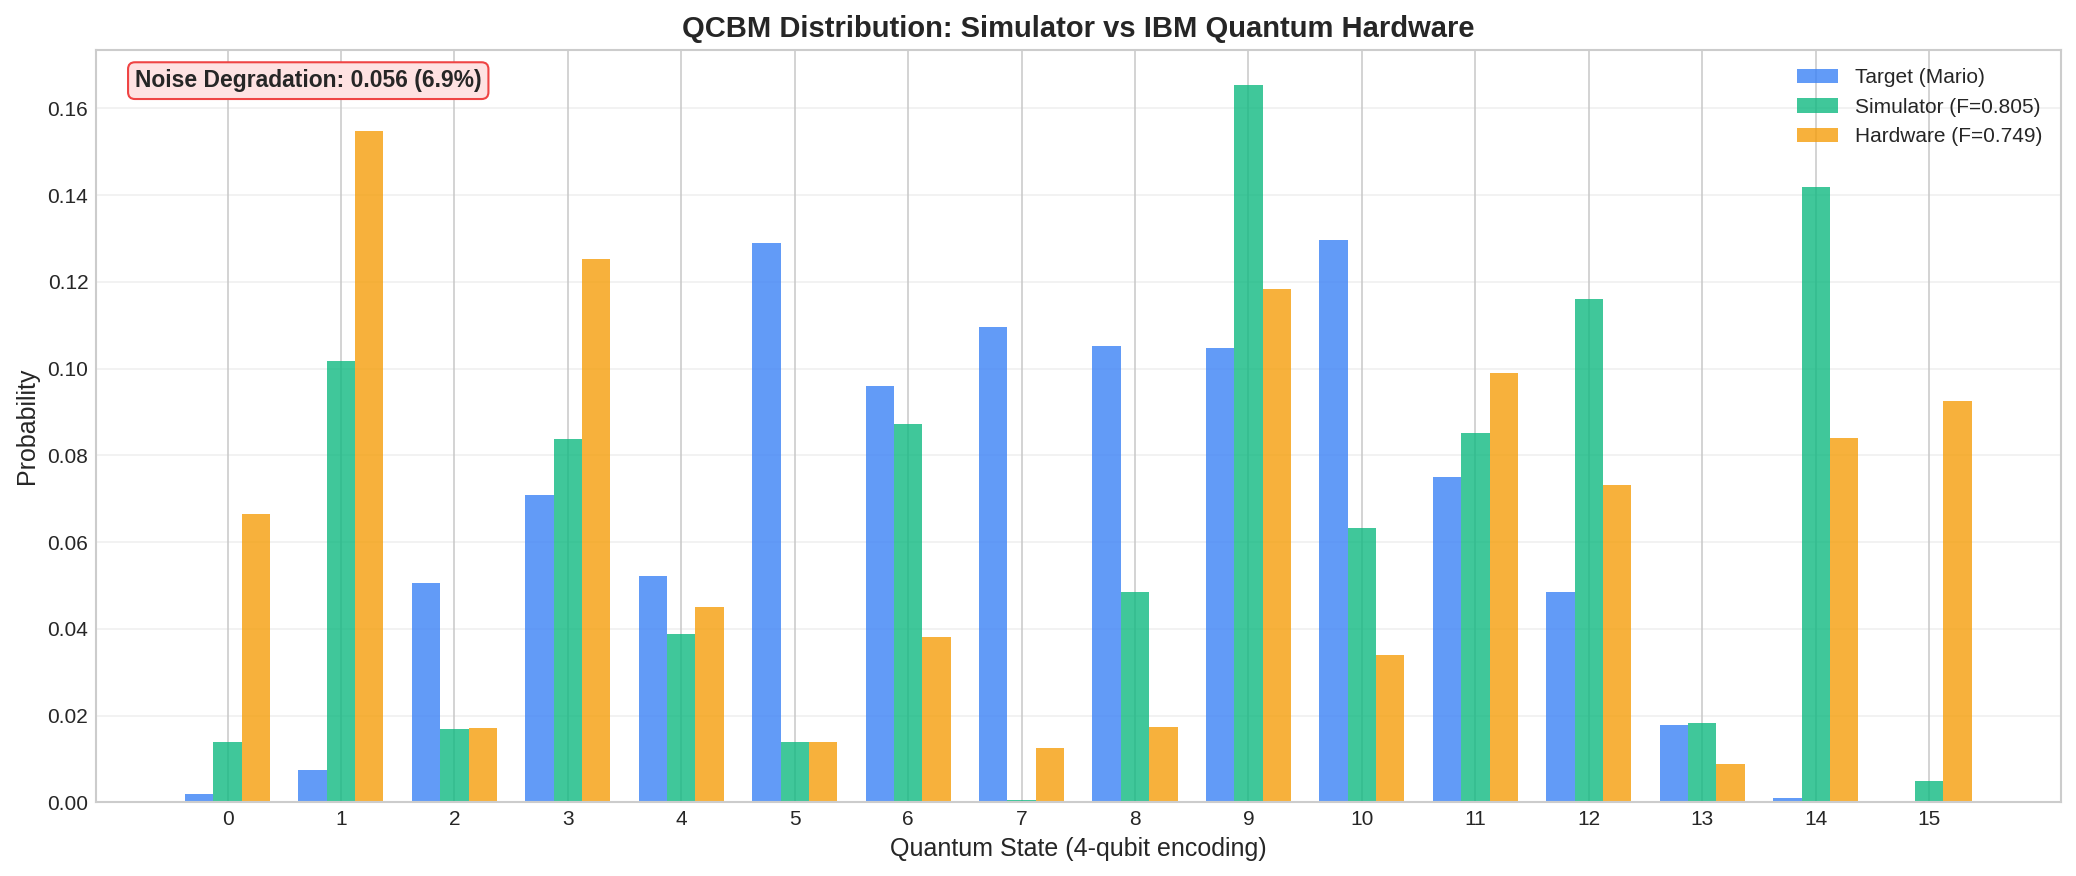

In [35]:
#  Step 5: Overlay Comparison Plot (Alternative Visualization)

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(target_dist))
width = 0.25

# Side-by-side bars
bars1 = ax.bar(x - width, target_dist, width, label='Target (Mario)', color='#3B82F6', alpha=0.8)
bars2 = ax.bar(x, final_probs, width, label=f'Simulator (F={final_fidelity:.3f})', color='#10B981', alpha=0.8)
bars3 = ax.bar(x + width, hardware_probs, width, label=f'Hardware (F={hw_fidelity:.3f})', color='#F59E0B', alpha=0.8)

ax.set_xlabel('Quantum State (4-qubit encoding)', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('QCBM Distribution: Simulator vs IBM Quantum Hardware', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Add noise degradation annotation
ax.annotate(f'Noise Degradation: {noise_degradation:.3f} ({noise_degradation/final_fidelity*100:.1f}%)',
            xy=(0.02, 0.95), xycoords='axes fraction',
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='#FEE2E2', edgecolor='#EF4444'))

plt.tight_layout()
save_figure(fig, 'hardware_vs_simulator_overlay', experiment='exp11')
plt.show()

In [37]:
#  Step 6: Save All Results for Report

import json
from datetime import datetime

# Add metadata
experiment_results['timestamp'] = datetime.now().isoformat()
experiment_results['backend_info'] = {
    'name': qiskit_qcbm.backend.name,
    'num_qubits': qiskit_qcbm.backend.num_qubits,
}

# Save to JSON
results_path = FIGURES_DIR / 'exp11_hardware_validation.json'
with open(results_path, 'w') as f:
    json.dump(experiment_results, f, indent=2)

print("="*70)
print(" RESULTS SAVED")
print("="*70)
print(f"\n Files saved to {FIGURES_DIR}/:")
print(f"   • exp11_hardware_validation.json      (all metrics)")
print(f"   • exp11_hardware_validation_comparison.png")
print(f"   • exp11_hardware_vs_simulator_overlay.png")

print("\n" + "="*70)
print(" SUMMARY FOR THESIS REPORT")
print("="*70)
print(f"""
Experiment: Hardware Validation of QCBM for Music Generation
Date: {datetime.now().strftime('%Y-%m-%d')}
Backend: IBM Quantum {qiskit_qcbm.backend.name} ({qiskit_qcbm.backend.num_qubits} qubits)

Circuit Configuration:
  - Qubits: {qiskit_qcbm.n_qubits}
  - Layers: {qiskit_qcbm.n_layers}
  - Parameters: {qiskit_qcbm.n_params}
  - Shots: {qiskit_qcbm.hardware_config.shots}

Results:
  - Simulator Fidelity:     {final_fidelity:.4f}
  - Hardware Fidelity:      {hw_fidelity:.4f}
  - Noise Degradation:      {noise_degradation:.4f} ({noise_degradation/final_fidelity*100:.1f}%)
  - Simulator-HW Agreement: {sim_hw_fidelity:.4f}
""")

 RESULTS SAVED

 Files saved to /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/:
   • exp11_hardware_validation.json      (all metrics)
   • exp11_hardware_validation_comparison.png
   • exp11_hardware_vs_simulator_overlay.png

 SUMMARY FOR THESIS REPORT

Experiment: Hardware Validation of QCBM for Music Generation
Date: 2026-02-06
Backend: IBM Quantum ibm_torino (133 qubits)

Circuit Configuration:
  - Qubits: 4
  - Layers: 3
  - Parameters: 24
  - Shots: 4096

Results:
  - Simulator Fidelity:     0.8053
  - Hardware Fidelity:      0.7495
  - Noise Degradation:      0.0558 (6.9%)
  - Simulator-HW Agreement: 0.9333



---
#  Summary

## Features Implemented:

| Feature | Description | Benefit |
|---------|-------------|---------|
| **Markov QCBM** | Temporal transitions between notes | Smoother, more musical sequences |
| **Duration Encoding** | 6-qubit pitch+duration model | Variable note lengths |
| **IBM Quantum** | Qiskit backend for real hardware | NISQ experimentation |

## Generated Files:
- `03_markov_qcbm_temporal_coherence.mid` - Temporally coherent melody
- `04_joint_pitch_rhythm_qcbm.mid` - Melody with variable durations
- `exp11_*.png` - Figures for report

## Key Equations:

**Markov QCBM:**
$$P(x_t | x_{t-1}) \propto P_{QCBM}(x_t)^{1-\alpha} \cdot T(x_t|x_{t-1})^{\alpha}$$

**Joint Encoding:**
$$\text{state} = \text{pitch\_bin} \times 4 + \text{duration\_bin}$$

In [38]:
print("\n" + "="*70)
print(" ADVANCED FEATURES EXPERIMENT COMPLETE!")
print("="*70)
print("\n    Temporal Modeling: Markov QCBM implemented")
print("    Duration Encoding: 6-qubit joint model")
print("    IBM Quantum: Qiskit backend ready")
print("\n" + "="*70)


 ADVANCED FEATURES EXPERIMENT COMPLETE!

    Temporal Modeling: Markov QCBM implemented
    Duration Encoding: 6-qubit joint model
    IBM Quantum: Qiskit backend ready

